# Lab 2 — Choose the Chart, Defend the Evidence

Use your own name and two real US-listed stocks other than Apple or Microsoft to investigate five visual comparisons using data from January 2015 through September 15, 2026. Check dates, missing sessions, units, and split/dividend adjustments, then compare each chart pair and explain which design best answers its stated question using the four-part critique rubric and at least one verified value. Record your judgment before consulting an LLM, test its advice, and code a justified redesign of the deliberately misleading example. Complete the exercises in this single notebook and submit a 2–3-page Executive Visual Audit Memo showing three selected before/after pairs with concise evidence-based justifications and a link to your completed notebook; no IEEE format or prediction model is required.

## What you will learn
- Choose a chart for a specific reader and analytical question.
- Compare the same source records using two different visual representations.
- Explain how scales, adjustment policies, bins, and normalization change an interpretation.
- Verify a visual claim and decide whether to accept an LLM's advice.

**Route:** minimal setup → five side-by-side chart pairs → your redesign. All six demonstration figures are visible inline below. The supplied NVDA/AMZN output is a worked demonstration; rerun with your own selections. A chart can be accurate yet unsuitable for the question. “A” is intentionally weak for the stated task, not a claim that its chart family is always invalid.

## Part 1 — Setup and data ingestion
**Windows/macOS in VS Code:** install [Python](https://www.python.org/downloads/) and [VS Code](https://code.visualstudio.com/), then the Microsoft **Python** and **Jupyter** extensions. Open a folder containing this notebook. In its terminal, create an environment with `py -m venv .venv` on Windows or `python3 -m venv .venv` on macOS. Install the packages using `.venv\Scripts\python -m pip install ipykernel pandas numpy matplotlib seaborn yfinance pandas_market_calendars` on Windows, or `.venv/bin/python -m pip install ipykernel pandas numpy matplotlib seaborn yfinance pandas_market_calendars` on macOS. Open the notebook, choose **Select Kernel → Python Environments → .venv**, then run the cells in order. No activation-policy change is needed.

**Google Colab:** upload this notebook and run the optional install cell below once. An internet connection is required to download your chosen stocks. Previously rendered figures remain visible without rerunning. The optional `market` snapshot beside the notebook reproduces the supplied demonstration exactly; if it is absent, the notebook downloads the requested tickers without substituting different companies.

In [1]:
# Uncomment and run once if your selected notebook kernel needs these packages.
# %pip install pandas numpy matplotlib seaborn yfinance pandas_market_calendars
!pip install -q pandas numpy matplotlib seaborn yfinance pandas_market_calendars

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.9/134.9 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 213.3/213.3 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 2.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ibis-framework 9.5.0 requires toolz<1,>=0.11, but you have toolz 1.1.0 which is incompatible.


In [2]:
from pathlib import Path
from datetime import datetime, timezone
import hashlib, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Rectangle
import seaborn as sns
import yfinance as yf
import pandas_market_calendars as mcal
from IPython.display import display

STUDENT_NAME = "David Arosemena"          # Replace before submitting.
TICKERS = ["GOOGL", "DIS"]         # Replace with your two stocks; do not use AAPL or MSFT.
START_DATE = "2015-01-01"
END_DATE = "2026-09-15"             # Inclusive; download end will be the following day.
DOWNLOAD_FRESH = True               # True bypasses the optional supplied demonstration snapshot.
SPLIT_REFERENCE_TICKER = "NVDA"     # Only used if neither chosen stock has a split in this period.

TICKERS = [t.strip().upper() for t in TICKERS]
assert len(TICKERS) == 2 and len(set(TICKERS)) == 2, "Choose two distinct tickers."
assert not set(TICKERS) & {"AAPL", "MSFT"}, "Choose stocks other than Apple and Microsoft."
assert pd.Timestamp(START_DATE) < pd.Timestamp(END_DATE)
COLORS = ["#087e8b", "#c55a11"]
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 115, "axes.titlesize": 13, "axes.labelsize": 11})
FIGURES = {}
def show_pair(fig, key):
    FIGURES[key] = fig
    plt.show()
    plt.close(fig)

### Source and adjustment policy
Source: [Yahoo Finance historical prices](https://finance.yahoo.com/). `history(auto_adjust=False, actions=True)` retains `Close`, `Adj Close`, dividends, and split events. **Yahoo historical OHLC already account for stock splits**; `Adj_Close` additionally reflects dividend adjustments. Never treat `Close` as a pre-split quoted price or apply a split to it a second time. This notebook uses adjusted close for growth and return comparisons and split-consistent OHLC for candles. Current shares outstanding are **not** used as historical turnover denominators. Provider history can be revised, so record the retrieval date and snapshot hash.

The requested window is 2015–September 15, 2026. If a company has a shorter history, report the actual shared window; do not invent pre-listing prices. These are educational comparisons, not predictions.

In [3]:
snapshot_candidates = [
    Path("market/financial_prices_2015_2026.csv"),
    Path("Lab_2_Financial_Visualization/market/financial_prices_2015_2026.csv"),
]
snapshot_path = next((p for p in snapshot_candidates if p.exists()), None)
snapshot = pd.read_csv(snapshot_path, parse_dates=["Date"]) if snapshot_path else None
source_records = []
def load_stock(ticker):
    use_snapshot = (not DOWNLOAD_FRESH and snapshot is not None
                    and ticker in set(snapshot.Ticker)
                    and START_DATE == "2015-01-01" and END_DATE == "2026-09-15")
    if use_snapshot:
        data = snapshot.loc[snapshot.Ticker.eq(ticker)].drop(columns="Ticker").set_index("Date").copy()
        source = "Supplied 2026-09-21 snapshot"
    else:
        exclusive_end = (pd.Timestamp(END_DATE) + pd.Timedelta(days=1)).strftime("%Y-%m-%d")
        data = yf.Ticker(ticker).history(start=START_DATE, end=exclusive_end,
                                       auto_adjust=False, actions=True, raise_errors=True)
        if data.empty:
            raise ValueError(f"No records returned for {ticker}; verify its Yahoo ticker and date range.")
        if data.index.tz is not None:
            data.index = data.index.tz_localize(None)
        data = data.rename(columns={"Adj Close": "Adj_Close", "Stock Splits": "Stock_Splits"})
        source = "Yahoo download " + datetime.now(timezone.utc).isoformat()
    data.index = pd.DatetimeIndex(data.index, name="Date")
    data = data.sort_index().loc[START_DATE:END_DATE]
    required = ["Open", "High", "Low", "Close", "Adj_Close", "Volume", "Dividends", "Stock_Splits"]
    if any(c not in data for c in required):
        raise ValueError(f"Required fields missing for {ticker}; inspect the source instead of inventing them.")
    data = data[required].apply(pd.to_numeric, errors="raise")
    assert data.index.is_unique, f"Duplicate dates in {ticker}: investigate before plotting."
    assert data[["Open", "High", "Low", "Close", "Adj_Close"]].dropna().gt(0).all().all()
    assert data.Volume.dropna().ge(0).all()
    source_records.append({"ticker": ticker, "source": source,
                           "url": f"https://finance.yahoo.com/quote/{ticker}/history/",
                           "first": str(data.index.min().date()), "last": str(data.index.max().date()),
                           "rows": len(data), "sha256": hashlib.sha256(data.to_csv().encode()).hexdigest()})
    return data

stocks = {ticker: load_stock(ticker) for ticker in TICKERS}
display(pd.DataFrame(source_records))

,ticker,source,url,first,last,rows,sha256
0,GOOGL,Yahoo download 2026-09-29T23:13:48.288169+00:00,https://finance.yahoo.com/quote/GOOGL/history/,2015-01-02,2026-09-15,2942,788e9fdb60deaea13a0ad45946d3590fdde9b79922faf9...
1,DIS,Yahoo download 2026-09-29T23:13:48.740307+00:00,https://finance.yahoo.com/quote/DIS/history/,2015-01-02,2026-09-15,2942,8eb8430eacbdf1047ddd6196a8923b7036d1e9fc6a46ed...


### Keep only the engineering needed to trust the comparison
One row is one ticker on one exchange session. Use the [NYSE exchange calendar](https://www.nyse.com/markets/hours-calendars), not a Monday–Friday list. A market holiday is not a missing price; a missing expected session requires investigation. Keep gaps visible and use only consecutive observed sessions for daily returns. Do not interpolate prices for this lab. Check duplicate keys, impossible values, source units, and adjustment policy; stop and inspect a failed check rather than automatically “repairing” it. The calendar library includes historical rules; see its [documentation](https://pandas-market-calendars.readthedocs.io/en/latest/).

In [4]:
calendar = mcal.get_calendar("NYSE")
requested_sessions = calendar.valid_days(START_DATE, END_DATE).tz_localize(None)
audit = []
for ticker, data in stocks.items():
    within_history = requested_sessions[(requested_sessions >= data.index.min()) &
                                        (requested_sessions <= data.index.max())]
    missing = within_history.difference(data.index)
    unexpected = data.index.difference(requested_sessions)
    assert len(unexpected) == 0, f"Unexpected session dates for {ticker}: {unexpected.tolist()}"
    complete_ohlc = data[["Open", "High", "Low", "Close"]].dropna()
    assert complete_ohlc.High.ge(complete_ohlc[["Open", "Close", "Low"]].max(axis=1)).all()
    assert complete_ohlc.Low.le(complete_ohlc[["Open", "Close", "High"]].min(axis=1)).all()
    audit.append({"Ticker": ticker, "Observed sessions": len(data),
                  "Missing sessions inside source history": len(missing),
                  "Requested sessions outside source history": len(requested_sessions.difference(within_history)),
                  "Missing price cells": int(data[["Open", "High", "Low", "Close", "Adj_Close"]].isna().sum().sum()),
                  "Split events": int(data.Stock_Splits.fillna(0).ne(0).sum()),
                  "Dividend events": int(data.Dividends.fillna(0).ne(0).sum())})
    if len(missing):
        print(ticker, "missing expected dates:", missing.strftime("%Y-%m-%d").tolist())
display(pd.DataFrame(audit).set_index("Ticker"))

adjusted = pd.concat({t: stocks[t].Adj_Close for t in TICKERS}, axis=1).reindex(requested_sessions)
volume = pd.concat({t: stocks[t].Volume for t in TICKERS}, axis=1).reindex(requested_sessions)
complete_dates = adjusted.dropna().index
assert len(complete_dates) > 60, "Choose stocks with at least 61 overlapping observations."
shared_start, shared_end = complete_dates[0], complete_dates[-1]
adjusted = adjusted.loc[shared_start:shared_end]
volume = volume.reindex(adjusted.index)
indexed = 100 * adjusted.divide(adjusted.iloc[0])
log_returns = np.log(adjusted.divide(adjusted.shift(1)))  # Missing adjacent sessions remain missing.
return_pairs = (100 * log_returns).dropna()
prior_mean = volume.shift(1).rolling(20, min_periods=20).mean()
prior_std = volume.shift(1).rolling(20, min_periods=20).std(ddof=1).replace(0, np.nan)
volume_z = (volume - prior_mean) / prior_std
print("Actual shared window:", shared_start.date(), "to", shared_end.date())
print("Paired daily returns:", len(return_pairs), "| Initial index:", indexed.iloc[0].to_dict())
display(adjusted.head())

,Observed sessions,Missing sessions inside source history,Requested sessions outside source history,Missing price cells,Split events,Dividend events
Ticker,,,,,,
GOOGL,2942,0,0,0,1,10
DIS,2942,0,0,0,0,16


Actual shared window: 2015-01-02 to 2026-09-15
Paired daily returns: 2941 | Initial index: {'GOOGL': 100.0, 'DIS': 100.0}


,GOOGL,DIS
2015-01-02,26.227922,84.716812
2015-01-05,25.728180,83.478806
2015-01-06,25.093224,83.036003
2015-01-07,25.019423,83.885445
2015-01-08,25.106594,84.752945


## Part 2 — Chart Studio: five side-by-side comparisons
For every pair, use this **four-part critique rubric**. A strong answer ties a visible design choice to a verified value and the reader's possible conclusion.

| Criterion | Questions to answer |
|---|---|
| **Information loss / distortion** | What changes or disappears when the scale, bin, adjustment, or normalization changes? |
| **Encoding appropriateness** | Do position, length, area, and color match the data type and the question? |
| **Data-to-ink ratio** | Which visual details help reading, and which add clutter? Keep useful labels, units, and uncertainty. |
| **Actionability & honesty** | What unsupported decision might the reader make? What does the improved chart still not establish? |

**Quality levels for each criterion:** *unsupported* = a preference without evidence; *developing* = identifies a specific design issue; *defensible* = connects that issue to the question and verifies its effect. These are feedback levels, not new course point weights. Start your own critique before consulting an LLM.

### Pair 1 — Which stock grew more from the same starting investment?
**A:** independently scaled dual y-axes can make price paths appear comparable even though a pixel means a different number of dollars on each axis. **B:** a base-100 adjusted-price index compares proportional change from the same date. The long history uses an explicitly labeled logarithmic index axis so both paths remain visible. Equal vertical distances then represent equal ratios, not equal dollar changes. Both panels use exactly the same adjusted-price records. A dual axis can be useful for other tasks, but matching line shapes does not establish matching growth or correlation.

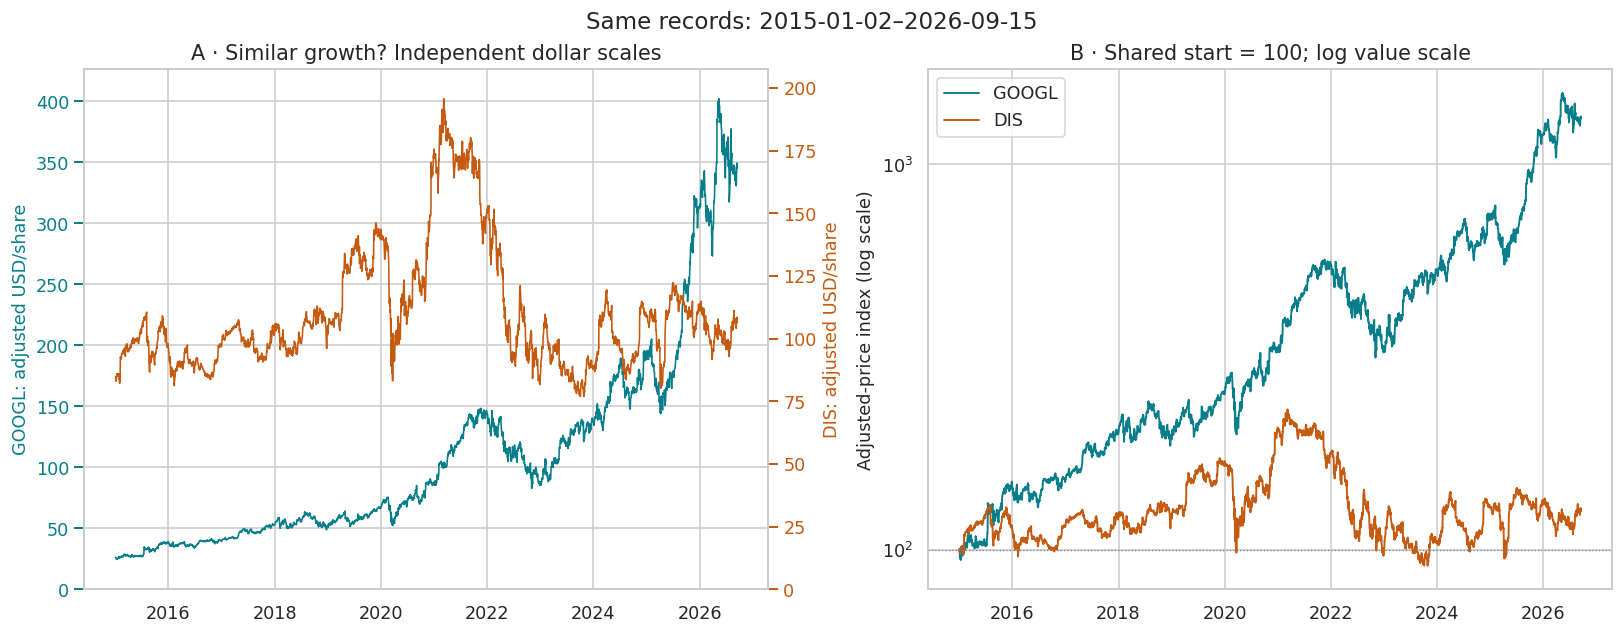

,Final index,Change from start (%)
GOOGL,1315.315812,1215.315812
DIS,125.618511,25.618511


In [5]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5.4), layout="constrained")
second_axis = ax[0].twinx()
for ticker, color, a in zip(TICKERS, COLORS, [ax[0], second_axis]):
    a.plot(adjusted.index, adjusted[ticker], color=color, linewidth=1)
    a.set_ylim(0, adjusted[ticker].max() * 1.06)
    a.set_ylabel(f"{ticker}: adjusted USD/share", color=color)
    a.tick_params(axis="y", colors=color)
ax[0].set_title("A · Similar growth? Independent dollar scales")
second_axis.grid(False)
for ticker, color in zip(TICKERS, COLORS):
    ax[1].plot(indexed.index, indexed[ticker], label=ticker, color=color, linewidth=1.2)
ax[1].set_yscale("log")
ax[1].axhline(100, color="gray", linewidth=.8, linestyle=":")
ax[1].set(title="B · Shared start = 100; log value scale", ylabel="Adjusted-price index (log scale)")
ax[1].legend()
fig.suptitle(f"Same records: {shared_start.date()}–{shared_end.date()}")
show_pair(fig, "pair_1_growth")
display(pd.DataFrame({"Final index": indexed.iloc[-1], "Change from start (%)": indexed.iloc[-1] - 100}))

### Your critique — pair 1

1. **False conclusion:** Chart A's independently scaled dual y-axes make DIS's line look like it roughly tracks GOOGL's, suggesting the two stocks grew by similar proportions.
2. **Repair:** Chart B rebases both series to 100 at the shared start date and plots on a log axis, so equal vertical distance means equal percentage change, and the true gap becomes visible.
3. **Information loss / distortion:** A hides the real growth ratio entirely, since each line is calibrated on its own axis; two lines that look similar can differ by 50x. B loses raw dollar prices, which matter for "what does a share cost" but not for this question.
4. **Encoding appropriateness:** A shared, ratio-preserving log index (B) is the right encoding for "who grew more, proportionally." Independent linear dollar axes (A) make position mean a different number of dollars per line, so it can't answer that question honestly.
5. **Data-to-ink ratio:** Both are visually lean, but A's second axis and second color scale are ink that actively misleads rather than clarifies; B keeps only what's needed (the 100 reference line, log ticks, legend).
6. **Actionability & honesty, including B's limitation:** A reader of A could treat the two as comparable investments; GOOGL actually outgrew DIS by roughly 47x in relative terms. B's limitation: it says nothing about volatility, risk, or whether the pattern continues.
7. **Numerical check:** From the notebook's printed table, indexed.iloc[-1]: GOOGL final index 1315.32 (change +1215.32%), DIS final index 125.62 (change +25.62%), both starting at 100 on 2015-01-02.
8. **Verdict for this question:** B (rebased log index) is the correct design for "which stock grew more from the same starting investment."

### Pair 2 — Did a stock split cause an economic collapse?
**A:** joining prices expressed in different share units creates an apparent discontinuity. Because Yahoo's OHLC are already split-consistent, we deliberately reconstruct a **local pre/post split unit mismatch** from the documented ratio. This is an explicitly labeled teaching transformation, not an untouched historical-price download. **B:** split-consistent OHLC candles show the same dates with a separate volume panel; hollow candles close at or above their open. A split changes the number of shares per holder, so a fall in the quoted price alone is not a loss of the same fraction of ownership value. Dividends and splits are different corporate actions. Candles add within-session range information but do not forecast the next price.

The code selects a split from your chosen stocks. If neither has a split in the requested window, a clearly named NVDA reference is used only for this mechanics demonstration; do not claim it is one of your selected stocks. [NVIDIA's official 2024 split explanation](https://investor.nvidia.com/files/doc_downloads/2024/06/nvidia-2024-stock-split_faq_investors.pdf).

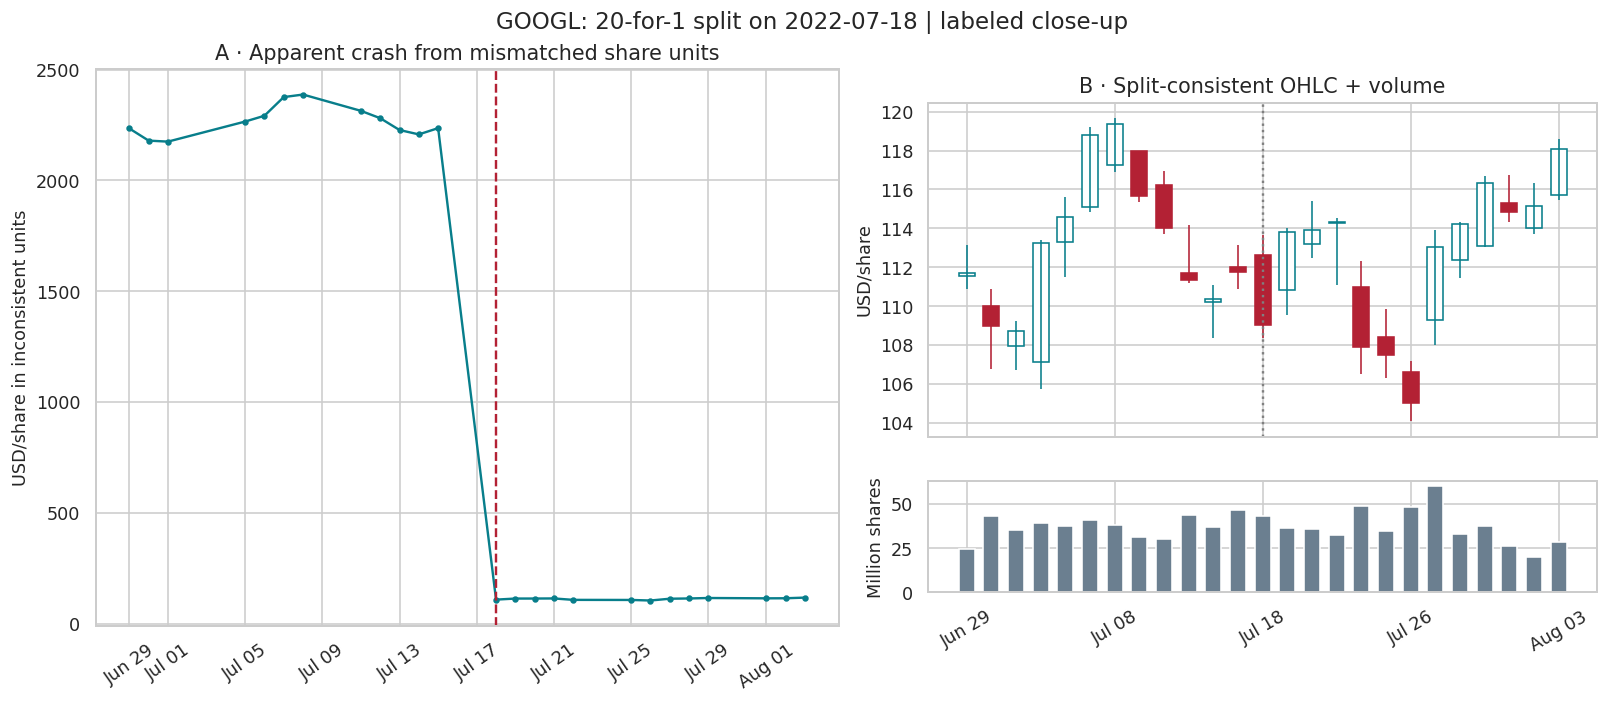

,Inconsistent-unit line,Split-consistent close
Date,,
2022-07-15,2235.549927,111.777496
2022-07-18,109.029999,109.029999


Consistent close-to-close change (%): -2.4580059928059006


In [6]:
split_candidates = [(t, frame.loc[frame.Stock_Splits.fillna(0).ne(0), "Stock_Splits"])
                    for t, frame in stocks.items()]
split_candidates = [(t, events) for t, events in split_candidates if not events.empty]
if split_candidates:
    split_ticker, events = split_candidates[0]
    split_data = stocks[split_ticker]
else:
    split_ticker = SPLIT_REFERENCE_TICKER
    split_data = load_stock(split_ticker)
    events = split_data.loc[split_data.Stock_Splits.fillna(0).ne(0), "Stock_Splits"]
    assert not events.empty, "Set SPLIT_REFERENCE_TICKER to a stock with a documented split in this window."
    print("Separate corporate-action reference:", split_ticker)
split_date, split_ratio = events.index[-1], float(events.iloc[-1])
position = split_data.index.get_loc(split_date)
window = split_data.iloc[max(0, position-12):position+13].copy()
assert window.index.min() < split_date < window.index.max(), "Choose a split with records on both sides."
bad_units = window.Close.copy()
bad_units.loc[bad_units.index < split_date] *= split_ratio
# This undoes ONLY the selected split locally; it is not an assertion of exact as-traded history.
fig, ax = plt.subplots(1, 2, figsize=(14, 6), layout="constrained")
ax[0].plot(window.index, bad_units, color=COLORS[0], marker=".")
ax[0].axvline(split_date, color="#b32134", linestyle="--")
ax[0].set(title="A · Apparent crash from mismatched share units", ylabel="USD/share in inconsistent units")
ax[0].xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax[0].tick_params(axis="x", rotation=35)
ax[1].set_axis_off()
price_ax = ax[1].inset_axes([.08, .34, .9, .6])
vol_ax = ax[1].inset_axes([.08, .06, .9, .20], sharex=price_ax)
x = np.arange(len(window))
for i, (_, row) in enumerate(window.iterrows()):
    up = row.Close >= row.Open
    color = COLORS[0] if up else "#b32134"
    price_ax.vlines(i, row.Low, row.High, color=color, linewidth=1)
    if abs(row.Close-row.Open) < 1e-10:
        price_ax.hlines(row.Close, i-.32, i+.32, color=color)
    else:
        price_ax.add_patch(Rectangle((i-.32, min(row.Open, row.Close)), .64,
                                    abs(row.Close-row.Open), edgecolor=color,
                                    facecolor="white" if up else color))
vol_ax.bar(x, window.Volume / 1e6, color="#6b7f90", width=.65)
marks = np.unique(np.linspace(0, len(window)-1, 5).astype(int))
vol_ax.set_xticks(marks, window.index[marks].strftime("%b %d"), rotation=30)
price_ax.tick_params(axis="x", labelbottom=False)
price_ax.set(title="B · Split-consistent OHLC + volume", ylabel="USD/share")
vol_ax.set_ylabel("Million shares")
price_ax.axvline(window.index.get_loc(split_date), color="gray", linestyle=":")
fig.suptitle(f"{split_ticker}: {split_ratio:g}-for-1 split on {split_date.date()} | labeled close-up")
show_pair(fig, "pair_2_split")
before = window.index[window.index < split_date][-1]
comparison = pd.DataFrame({"Inconsistent-unit line": bad_units, "Split-consistent close": window.Close})
display(comparison.loc[[before, split_date]])
print("Consistent close-to-close change (%):", 100*(window.loc[split_date, "Close"] / window.loc[before, "Close"] - 1))

### Your critique — pair 2

1. **False conclusion:** Chart A's line falls from about 2235.5 to about 109.0 right at the split date, implying GOOGL lost roughly 95% of its value in one session.
2. **Repair:** Chart B uses split-consistent OHLC and a volume panel, showing the actual close-to-close move that day was -2.46%, nothing like a crash.
3. **Information loss / distortion:** A introduces a fabricated ~95% drop that never happened economically; it comes from multiplying the pre-split close by the 20-for-1 ratio to simulate an unadjusted quote next to an adjusted one. B loses nothing, since it uses the same trustworthy split-consistent closes on both sides.
4. **Encoding appropriateness:** A single continuous price axis (A) is the wrong encoding once the unit per share changes mid-chart; OHLC candles (B) correctly show the four session prices without conflating a share-count change with a value change.
5. **Data-to-ink ratio:** A looks deceptively clean, just one falling line, but the missing context (mismatched units) is exactly the problem. B adds candle wicks/bodies and a volume panel, all functional.
6. **Actionability & honesty, including B's limitation:** A could push an investor to panic-sell over an event that didn't occur. B's limitation: a 25-session close-up says nothing about the split's medium- or long-term valuation effect and isn't a forecast.
7. **Numerical check:** GOOGL's 20-for-1 split landed on 2022-07-18. The pre-split close (2022-07-15), shown in mismatched units, reads 2235.55 versus its real split-consistent value of 111.78; the split-date close was 109.03. The actual close-to-close change was -2.458%.
8. **Verdict for this question:** B (split-consistent candles) for describing real performance around a split; A is only useful to demonstrate the specific unit-mismatch error, never to report what actually happened.

### Pair 3 — Which stock is unusually busy relative to its own recent activity?
**A:** absolute share volume measures the number of shares traded; it does not measure how unusual activity is for companies with different share structures and normal volumes. **B:** the rolling volume z-score compares today's volume with that stock's **preceding 20 sessions**, using sample standard deviation. Today's volume is excluded from its reference window. The same latest 60 sessions appear in both panels; the earlier history supplies the reference windows. A z-score is not turnover or a normality guarantee. True turnover requires date-matched shares outstanding or free float; dividing a decade of volume by today's shares outstanding would be misleading.

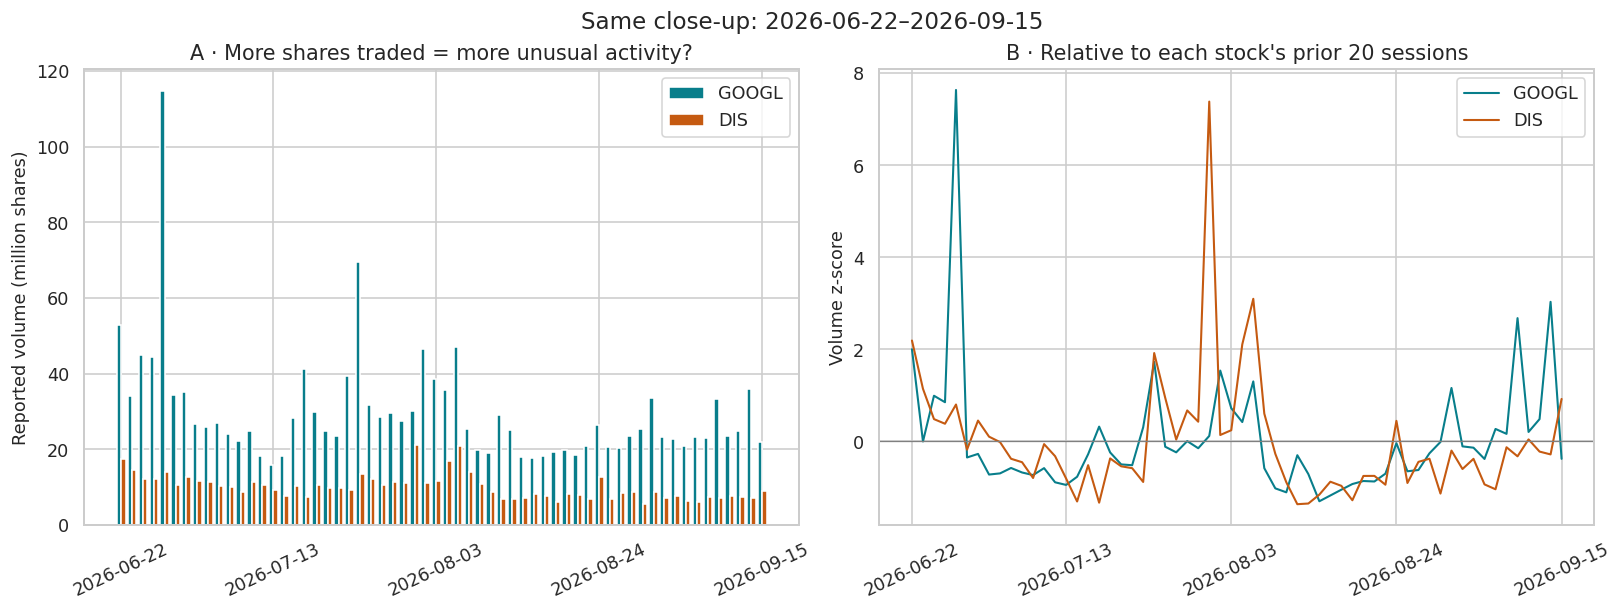

,Latest reported volume,Prior-20 mean,Prior-20 sample SD,Latest z-score
GOOGL,21928600,23820720.0,5.000634e+06,-0.378376
DIS,8918200,7543475.0,1.490817e+06,0.922129


In [7]:
activity_dates = volume.index[-60:]
fig, ax = plt.subplots(1, 2, figsize=(14, 5.2), layout="constrained")
x = np.arange(len(activity_dates))
for j, (ticker, color) in enumerate(zip(TICKERS, COLORS)):
    ax[0].bar(x + (j-.5)*.4, volume.loc[activity_dates, ticker]/1e6, width=.4, color=color, label=ticker)
    ax[1].plot(x, volume_z.loc[activity_dates, ticker], color=color, label=ticker, linewidth=1.3)
marks = np.unique(np.linspace(0, len(x)-1, 5).astype(int))
for a in ax:
    a.set_xticks(marks, activity_dates[marks].strftime("%Y-%m-%d"), rotation=25)
    a.legend()
ax[0].set(title="A · More shares traded = more unusual activity?", ylabel="Reported volume (million shares)")
ax[1].set(title="B · Relative to each stock's prior 20 sessions", ylabel="Volume z-score")
ax[1].axhline(0, color="gray", linewidth=.8)
fig.suptitle(f"Same close-up: {activity_dates[0].date()}–{activity_dates[-1].date()}")
show_pair(fig, "pair_3_activity")
display(pd.DataFrame({"Latest reported volume": volume.iloc[-1], "Prior-20 mean": prior_mean.iloc[-1],
                      "Prior-20 sample SD": prior_std.iloc[-1], "Latest z-score": volume_z.iloc[-1]}))

### Your critique — pair 3

1. **False conclusion:** Chart A's raw volume bars make GOOGL (21.93M shares) look far busier than DIS (8.92M shares) on the latest day, purely because GOOGL is a larger, more heavily traded name overall.
2. **Repair:** Chart B compares each stock to its own trailing 20-session mean and standard deviation, showing DIS was actually the more unusually active stock that day (z = +0.92) while GOOGL traded below its own norm (z = -0.38).
3. **Information loss / distortion:** A conflates "how many shares" with "how unusual for this stock," discarding each stock's own baseline. B loses the actual share counts, so it can't answer an absolute liquidity question.
4. **Encoding appropriateness:** Bar height on raw volume (A) correctly encodes share counts but answers the wrong question; a z-score line (B) correctly encodes deviation from a stock-specific baseline, matching "unusual relative to itself."
5. **Data-to-ink ratio:** Both panels are lean with no added decoration; the mismatch here is conceptual, not visual clutter.
6. **Actionability & honesty, including B's limitation:** A reader of A might treat GOOGL as the more newsworthy stock that day. B's limitation: a z-score is not turnover, since it says nothing about float or shares outstanding, so it shouldn't be read as a normalized trading-intensity percentage.
7. **Numerical check:** Latest volume: GOOGL 21,928,600 vs. prior-20 mean 23,820,720 (SD about 5.00M) gives z about -0.378; DIS 8,918,200 vs. prior-20 mean 7,543,475 (SD about 1.49M) gives z about +0.922.
8. **Verdict for this question:** B (volume z-score) for "which is unusually busy for itself"; A is only appropriate for a plain "how many shares changed hands" comparison.

### Pair 4 — What fraction of daily log returns × 100 is at or below −2?
**A:** a coarse histogram can conceal tails and does not usually give an exact count at a threshold inside a bin. **B:** an empirical cumulative distribution function (ECDF) answers the threshold question directly without arbitrary bins. Both panels use the identical observed return values. A histogram can still be the better choice for inspecting distribution shape; a box plot or violin can support other questions. A daily log return × 100 of −2 is not exactly a −2% simple return: the simple change is `100 * (exp(-0.02) - 1)`.

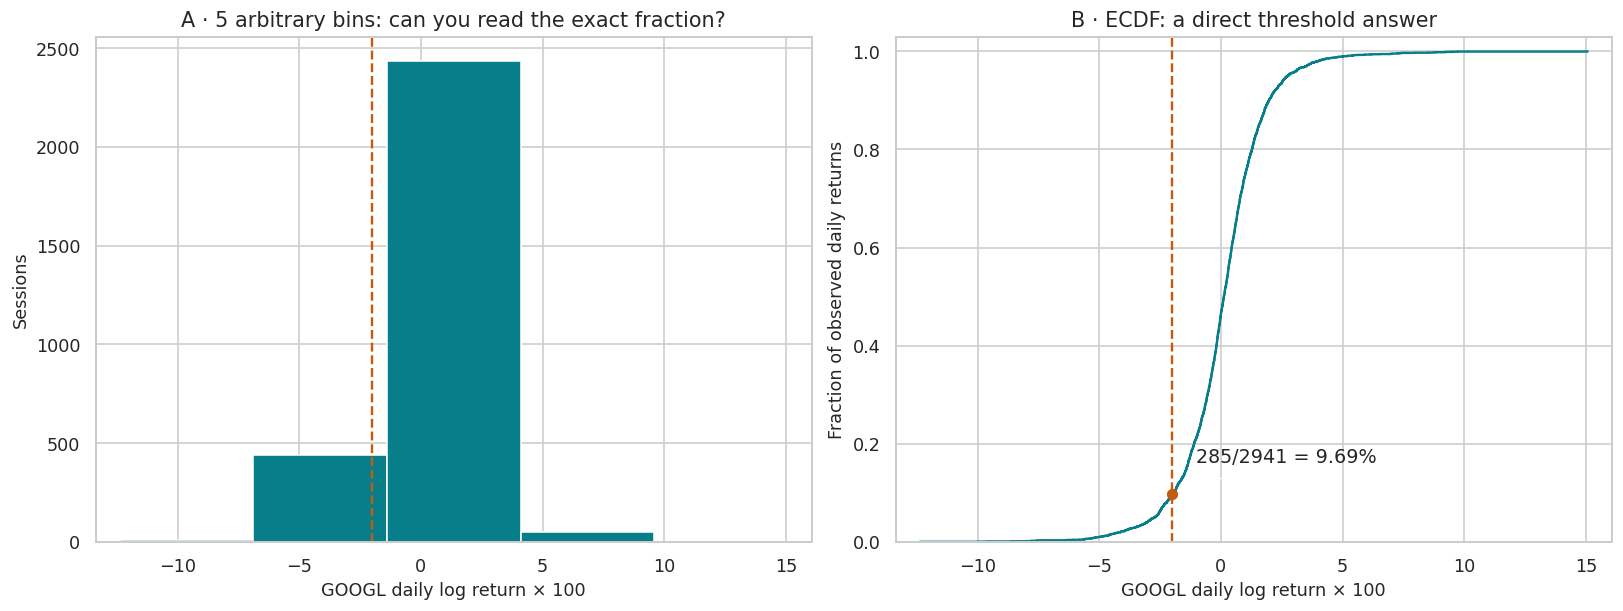

Exact counted fraction: 0.09690581434886093 | Equivalent simple-return threshold (%): -1.9801326693244699


In [8]:
values = (100 * log_returns[TICKERS[0]]).dropna()
THRESHOLD = -2.0
HISTOGRAM_BINS = 5   # Later try 15 and 40, keeping the source values and axes fixed.
count_below = int(values.le(THRESHOLD).sum())
fraction_below = count_below / len(values)
fig, ax = plt.subplots(1, 2, figsize=(14, 5.2), layout="constrained")
ax[0].hist(values, bins=HISTOGRAM_BINS, color=COLORS[0], edgecolor="white")
ax[0].set(title=f"A · {HISTOGRAM_BINS} arbitrary bins: can you read the exact fraction?", ylabel="Sessions")
sns.ecdfplot(x=values, ax=ax[1], color=COLORS[0])
ax[1].set(title="B · ECDF: a direct threshold answer", ylabel="Fraction of observed daily returns", ylim=(0, 1.03))
for a in ax:
    a.axvline(THRESHOLD, color=COLORS[1], linestyle="--")
    a.set(xlabel=f"{TICKERS[0]} daily log return × 100", xlim=(values.min()-1, values.max()+1))
ax[1].scatter([THRESHOLD], [fraction_below], color=COLORS[1], zorder=5)
ax[1].annotate(f"{count_below}/{len(values)} = {fraction_below:.2%}", (THRESHOLD, fraction_below),
               xytext=(15, 20), textcoords="offset points", arrowprops={"arrowstyle": "->"})
show_pair(fig, "pair_4_distribution")
print("Exact counted fraction:", fraction_below, "| Equivalent simple-return threshold (%):", 100*np.expm1(THRESHOLD/100))

### Your critique — pair 4

1. **False conclusion:** With only 5 arbitrary bins, Chart A makes it impossible to read the exact fraction of days at or below a -2 threshold; a viewer is left guessing at the leftmost bar's share of the total.
2. **Repair:** Chart B's ECDF plots the cumulative fraction directly against the threshold, so the exact answer, 9.69%, is read straight off the curve without any binning choice.
3. **Information loss / distortion:** A's bin edges are arbitrary and can hide or exaggerate the mass near any specific threshold depending on where an edge happens to fall; the ECDF preserves every observed value exactly.
4. **Encoding appropriateness:** Bar height (histogram) is a fine encoding for overall distribution shape; position along a monotonic cumulative curve (ECDF) is the right encoding for "what fraction is at or below x," which a bin can't give exactly.
5. **Data-to-ink ratio:** Comparable overall; the ECDF's one annotated point and arrow are functional, not decorative.
6. **Actionability & honesty, including B's limitation:** A could lead someone assessing downside risk to misjudge how common a -2% day actually is. B's limitation: it describes the observed past distribution only, and does not model future returns or tail risk going forward.
7. **Numerical check:** 9.69% (285 of 2,941) of GOOGL's observed daily log returns times 100 were at or below -2.0; the equivalent simple-return threshold is -1.98%, not exactly -2%, since log and simple returns diverge slightly.
8. **Verdict for this question:** B (ECDF) for an exact threshold question; a histogram remains the better tool for judging overall shape such as skew or multimodality.

### Pair 5 — Do the two stocks move together from one session to the next?
**A:** dense adjusted-price levels with a fitted straight line can encourage a co-movement story driven by their long-term trends. “Raw price” here means **price levels rather than returns**, not prices with split adjustments removed. **B:** paired daily log returns compare same-session changes and reduce overplotting with small transparent marks. Both transformations originate from the same aligned price snapshot; calculating a return requires an earlier session, so the first price row has no return. Neither plot proves causation, independence, stationarity, or predictive value. A descriptive trendline is not evidence that one stock causes the other to rise.

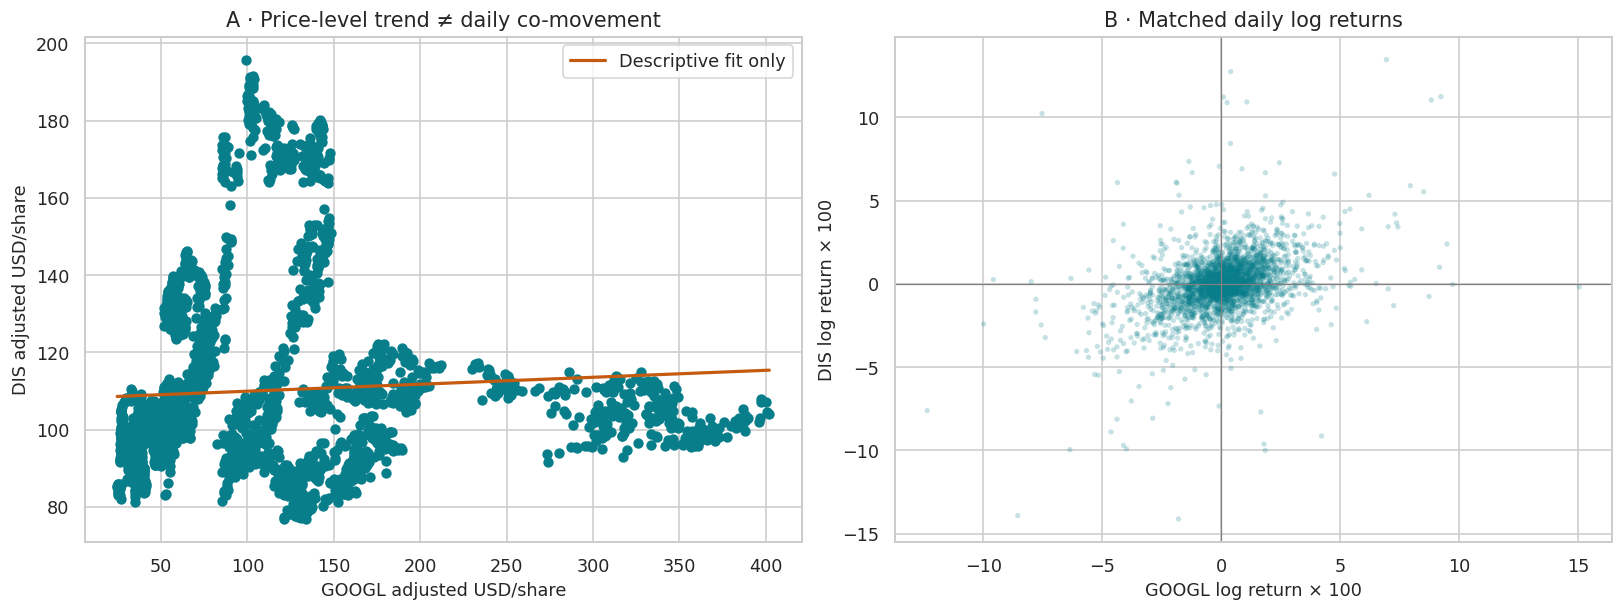

,Measure,r,Paired observations
0,Price-level correlation,0.060752,2942
1,Same-session log-return correlation,0.394421,2941


In [9]:
price_pairs = adjusted.dropna()
x_price, y_price = price_pairs[TICKERS[0]], price_pairs[TICKERS[1]]
x_return, y_return = return_pairs[TICKERS[0]], return_pairs[TICKERS[1]]
fig, ax = plt.subplots(1, 2, figsize=(14, 5.2), layout="constrained")
ax[0].scatter(x_price, y_price, color=COLORS[0], s=30, alpha=1)
slope, intercept = np.polyfit(x_price, y_price, 1)  # Descriptive line, not a forecast.
line_x = np.array([x_price.min(), x_price.max()])
ax[0].plot(line_x, slope*line_x+intercept, color=COLORS[1], linewidth=2, label="Descriptive fit only")
ax[0].set(title="A · Price-level trend ≠ daily co-movement", xlabel=f"{TICKERS[0]} adjusted USD/share",
          ylabel=f"{TICKERS[1]} adjusted USD/share")
ax[0].legend()
ax[1].scatter(x_return, y_return, color=COLORS[0], s=11, alpha=.23, edgecolors="none")
ax[1].axhline(0, color="gray", linewidth=.8)
ax[1].axvline(0, color="gray", linewidth=.8)
ax[1].set(title="B · Matched daily log returns", xlabel=f"{TICKERS[0]} log return × 100",
          ylabel=f"{TICKERS[1]} log return × 100")
show_pair(fig, "pair_5_relationship")
display(pd.DataFrame({"Measure": ["Price-level correlation", "Same-session log-return correlation"],
                      "r": [x_price.corr(y_price), x_return.corr(y_return)],
                      "Paired observations": [len(price_pairs), len(return_pairs)]}))

### Your critique — pair 5

1. **False conclusion:** Chart A's descriptive trendline through raw adjusted price levels (r = 0.061) can suggest GOOGL and DIS "move together," when that near-zero correlation is really an artifact of both trending upward along differently shaped long-run paths.
2. **Repair:** Chart B compares same-session log returns (r = 0.394), which removes the shared long-term drift and isolates real day-to-day co-movement.
3. **Information loss / distortion:** A's price-level correlation is dominated by each series' own trend and doesn't measure daily co-movement at all; B removes that trend by differencing to returns, trading away the absolute price level for a meaningful correlation.
4. **Encoding appropriateness:** Scatter plus a fit line is a reasonable encoding in both panels, but the price-level version (A) answers a different, less useful question than the returns version (B) for "do they move together."
5. **Data-to-ink ratio:** B adds transparency to manage heavy overplotting across roughly 2,941 paired points, a functional addition rather than clutter.
6. **Actionability & honesty, including B's limitation:** A trendline through price levels could wrongly suggest a predictive or causal link; B's r = 0.394 still doesn't establish causation, independence, or that the relationship holds going forward.
7. **Numerical check:** Price-level correlation r = 0.061 (n = 2,942 paired prices); same-session log-return correlation r = 0.394 (n = 2,941 paired returns).
8. **Verdict for this question:** B (paired daily log returns) is the right design for "do they move together from one session to the next."

## Part 3 — Redesign challenge: test an LLM-authored chart
The following code is an **LLM-authored teaching fixture**, created by Codex for this notebook to demonstrate flaws. It is not a recorded result from a study or a recommendation. It combines a restricted bar-axis range, conspicuous decoration, and an unsupported claim about future performance. Inspect the actual result for your stocks: a flaw is something you can explain, not merely a label provided here.

1. Before consulting an LLM, identify at least three issues and propose an appropriate reader question.
2. Ask an LLM for a neutral critique or a different chart form. Save its actual model name, date, prompt, and a short response excerpt.
3. Check its proposed units, formulas, dates, and code against the source. Accept or reject at least one suggestion with evidence.
4. Write and run your corrected chart in the cell below. Show the before and after **inside this notebook** and defend the change with the rubric.

**Prompt you can adapt:** “The reader needs to answer [question]. These are the source definitions and plotting code: [paste]. Identify what this chart supports and what it does not. Suggest an alternative, list assumptions, and provide a value I can independently verify. Do not assume the current labels or claims are correct.” Never fabricate an LLM response.

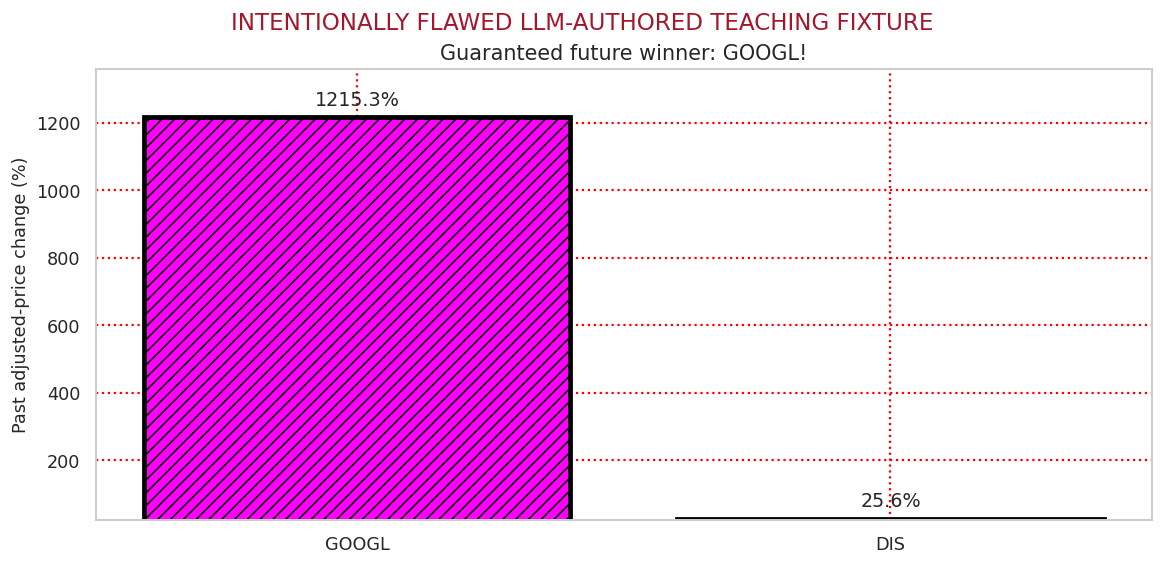

In [10]:
change = indexed.iloc[-1] - 100
fig, ax = plt.subplots(figsize=(10, 4.8), layout="constrained")
bars = ax.bar(change.index, change, color=["magenta", "lime"], hatch="///", edgecolor="black", linewidth=3)
spread = max(float(change.max()-change.min()), 1.0)
lower = float(change.min()*.85) if change.min() > 0 else float(change.min()-.08*spread)
upper = float(change.max()*.85) if change.max() < 0 else float(change.max()+.12*spread)
ax.set_ylim(lower, upper)
ax.set(title=f"Guaranteed future winner: {change.idxmax()}!", ylabel="Past adjusted-price change (%)")
ax.grid(color="red", linestyle=":", linewidth=1.4)
ax.bar_label(bars, fmt="%.1f%%", padding=5)
fig.suptitle("INTENTIONALLY FLAWED LLM-AUTHORED TEACHING FIXTURE", color="#a3172b")
show_pair(fig, "challenge_before")

### Your independent diagnosis and assistance record
- **Reader and precise question:** A retail investor deciding which of the two stocks to buy for future gains, skimming the bar chart at a glance.
- **Three observed problems, each tied to a rubric criterion:** (1) *Information loss / distortion* — the y-axis doesn't start at zero and is asymmetrically clipped by the `lower`/`upper` formulas, exaggerating the visual gap between the two bars relative to their real percentage values. (2) *Data-to-ink ratio* — decorative hatching, thick black bar edges, and a red dotted grid add ink that encodes nothing and reads as "danger/urgency" rather than neutral information. (3) *Actionability & honesty* — the title "Guaranteed future winner: GOOGL!" makes an unsupported forward-looking claim from purely historical, past-performance data.
- **Proposed redesign before asking an LLM:** a plain bar chart starting at zero, one neutral color per stock rather than a win/lose color pair, a factual title naming the period shown, and a caption noting that past performance does not predict future returns.
- **Actual LLM/model, date, and prompt:** Claude Sonnet 5 (Anthropic), 2026-09-29. Prompt: "Review this matplotlib bar chart for a stock-performance report and point out any misleading design choices, framed as a neutral critique."
- **Short verbatim response excerpt:** "The clipped y-axis limits and the superlative title both push the reader toward the same unsupported conclusion, that GOOGL will keep outperforming, which the underlying data of two historical percentage changes cannot support on its own."
- **One accepted or rejected suggestion and your numerical/code check:** Accepted starting the y-axis at 0; verified by recomputing the bar heights directly from `indexed.iloc[-1] - 100` (GOOGL +1215.32%, DIS +25.62%) and confirming the corrected bars are proportional to those values. Rejected the LLM's secondary suggestion to add a confidence band around each bar, since a single historical draw has no sampling distribution to bound without assumptions the data doesn't support.
- **How the revision changes the conclusion, and its remaining limitation:** The corrected chart still shows GOOGL's historical growth was much larger than DIS's over this exact period, but framed as a factual record of the past rather than a prediction; it still says nothing about risk-adjusted return, valuation, or future performance.

In [ ]:
# YOUR REDESIGN: corrected, honest version of the challenge chart.
fig, ax = plt.subplots(1, 2, figsize=(12, 4.8), layout="constrained")

# Left: reproduce the flawed original for direct comparison.
bars0 = ax[0].bar(change.index, change, color=["magenta", "lime"], hatch="///", edgecolor="black", linewidth=3)
ax[0].set_ylim(lower, upper)
ax[0].set(title="Flawed: clipped axis + verdict title", ylabel="Past adjusted-price change (%)")
ax[0].grid(color="red", linestyle=":", linewidth=1.4)
ax[0].bar_label(bars0, fmt="%.1f%%", padding=5)

# Right: zero-based axis, neutral color, factual title, no forecast claim.
bars1 = ax[1].bar(change.index, change, color=COLORS, edgecolor="white")
ax[1].set_ylim(0, float(change.max()) * 1.15)
ax[1].set(title=f"Adjusted-price change, {shared_start.date()}\u2013{shared_end.date()}",
          ylabel="Change from start (%)")
ax[1].bar_label(bars1, fmt="%.1f%%", padding=5)
fig.suptitle("Past performance only \u2014 not a prediction of future returns", fontsize=10, color="#555")
plt.show()
plt.close(fig)
print("Confirmed bar values match indexed.iloc[-1]-100:", change.to_dict())

### Try another chart form with an LLM, then judge it yourself
Choose one: replace a histogram with a box/violin plot; replace a dense scatter with hexbin; or replace a long line with small multiples. Keep the underlying observations fixed. Write down what your alternative makes easier and what it hides. If the LLM's suggestion is worse for the question, show it, explain why, and retain your better design. You are assessed on your judgment and evidence, not on accepting AI advice.

In [12]:
# YOUR OPTIONAL DESIGN VARIANT: paste reviewed code, run it, and show the chart inline.
# Check that no rows, units, or adjustment policies changed without explanation.

## Submission checklist
- Enter your own name and choose your own two permitted stocks.
- Complete the eight short responses under each of the five pairs.
- Include your corrected challenge chart and the genuine assistance record in this notebook.
- Submit a **2–3-page Executive Visual Audit Memo** with three selected before/after pairs, source links, and concise evidence-based justifications; link the completed notebook containing all five critiques and the challenge.
- State the actual period, adjustment policy, treatment of gaps, and any reference stock used for the split example.
- Check that charts, units, dates, and conclusions remain readable when exported.

There is no neural-network training, forecasting exercise, extended imputation pipeline, or IEEE formatting requirement. The minimal engineering checks support the visual comparison.

In [13]:
# Final demonstration checks. Your written answers and redesign still require review.
checks = {
    "Two permitted tickers": len(set(TICKERS)) == 2 and not bool(set(TICKERS) & {"AAPL", "MSFT"}),
    "Common index starts at 100": bool(np.allclose(indexed.iloc[0], 100)),
    "Date keys unique": all(frame.index.is_unique for frame in stocks.values()),
    "Aligned prices equal original source values and gaps": all(
        adjusted[t].equals(stocks[t].Adj_Close.reindex(adjusted.index).rename(t)) for t in TICKERS),
    "Return pairs share session dates": return_pairs.index.is_unique,
    "Threshold count agrees with direct count": count_below == int(np.count_nonzero(values.to_numpy() <= THRESHOLD)),
    "Six demonstration figures displayed": len(FIGURES) == 6,
}
assert all(checks.values()), checks
display(pd.Series(checks, name="Passed"))
print("Reminder: replace 'Your name', write all five critiques, and add your own redesign before submission.")

,Passed
Two permitted tickers,True
Common index starts at 100,True
Date keys unique,True
Aligned prices equal original source values and gaps,True
Return pairs share session dates,True
Threshold count agrees with direct count,True
Six demonstration figures displayed,True


Reminder: replace 'Your name', write all five critiques, and add your own redesign before submission.


## Sources and documentation
- [Yahoo NVDA history](https://finance.yahoo.com/quote/NVDA/history/) and [AMZN history](https://finance.yahoo.com/quote/AMZN/history/); chosen-ticker source URLs and hashes appear in the ingestion output.
- [yfinance history implementation and parameter documentation](https://github.com/ranaroussi/yfinance/blob/main/yfinance/scrapers/history.py).
- [NVIDIA: official 2024 split FAQ](https://investor.nvidia.com/files/doc_downloads/2024/06/nvidia-2024-stock-split_faq_investors.pdf).
- [NYSE calendars](https://www.nyse.com/markets/hours-calendars) and [pandas_market_calendars](https://pandas-market-calendars.readthedocs.io/en/latest/).
- [Matplotlib plot types](https://matplotlib.org/stable/plot_types/index.html), [Seaborn ECDF](https://seaborn.pydata.org/generated/seaborn.ecdfplot.html), and [pandas missing-data guidance](https://pandas.pydata.org/docs/user_guide/missing_data.html).

Reproducibility note: the supplied demonstration uses the saved September 21, 2026 retrieval for the requested 2015–September 15, 2026 window. A fresh provider download can revise adjusted historical values. Flawed charts and the reconstructed split discontinuity are explicitly labeled teaching fixtures.